In [7]:
import pandas as pd
from pathlib import Path
import numpy as np
from graphlaplacianoptimizer._build_direct import build_arrowspace

ROOT = Path.cwd().parent

DATA_DIR = ROOT / "data"
# Path to your parquet file
file_path = DATA_DIR / "cve1999-2025.parquet"

# Read the parquet file
df = pd.read_parquet(file_path)

# Print the first 5 rows
df.head(5)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_374,col_375,col_376,col_377,col_378,col_379,col_380,col_381,col_382,col_383
0,-0.058242,0.143897,0.050949,0.044082,-0.010660,-0.030449,-0.102678,-0.071708,-0.019558,0.064573,...,0.007179,-0.068312,0.013671,-0.087911,-0.008179,-0.008545,0.090575,-0.001451,-0.038536,0.037249
1,0.021119,0.055842,-0.072913,0.014004,-0.034930,-0.008704,0.023771,-0.051972,-0.015190,0.063693,...,0.014335,0.009201,0.054172,0.034092,0.058295,0.062804,-0.063012,0.013626,0.037771,-0.086374
2,0.002411,0.093139,0.066600,-0.035568,-0.032703,-0.061105,-0.081417,-0.099211,-0.023001,0.050815,...,0.040710,-0.026192,-0.031956,-0.099937,0.029413,-0.052322,0.102368,0.019560,-0.012578,0.094946
3,0.107001,0.036205,0.046087,0.002699,-0.069027,-0.039472,-0.031320,0.059566,0.000769,-0.022243,...,-0.008873,0.007778,-0.032090,0.005314,0.045760,0.046557,0.009942,0.122582,0.082310,-0.021578
4,-0.002006,0.051426,0.125028,-0.007355,0.010223,-0.037492,0.010652,-0.012433,0.023163,-0.026779,...,0.002962,0.053974,-0.080159,-0.020568,0.020258,-0.009890,0.075090,-0.092456,-0.002020,0.084293


In [2]:
print(len(df))

313841


In [6]:
import pandas as pd

# Your data
trials = [
    {'trial':4,  'eps':10.849781, 'k':18, 'topk':306, 'p':2.862820, 'sigma':0.40962,  'score':7.476875,  'build_time':95.85},
    {'trial':5,  'eps':1.840770,  'k':26, 'topk':87,  'p':1.514465, 'sigma':0.775953, 'score':0.525012,  'build_time':71.91},
    {'trial':6,  'eps':1.356138,  'k':16, 'topk':304, 'p':2.741605, 'sigma':0.191331, 'score':1.050751,  'build_time':92.72},
    {'trial':7,  'eps':0.863160,  'k':10, 'topk':273, 'p':2.498045, 'sigma':0.142482, 'score':0.150278,  'build_time':63.19},
    {'trial':8,  'eps':7.620174,  'k':14, 'topk':112, 'p':1.235454, 'sigma':0.897177, 'score':0.878047,  'build_time':73.35},
    {'trial':9,  'eps':1.456790,  'k':27, 'topk':346, 'p':2.073984, 'sigma':2.316709, 'score':0.030885,  'build_time':93.77},
    {'trial':10, 'eps':2.072999,  'k':22, 'topk':312, 'p':2.031457, 'sigma':0.130073, 'score':0.348514,  'build_time':94.97},
    {'trial':11, 'eps':11.387668, 'k':21, 'topk':493, 'p':2.986029, 'sigma':0.346947, 'score':2.332761,  'build_time':99.50},
    {'trial':12, 'eps':11.918332, 'k':21, 'topk':493, 'p':2.941944, 'sigma':0.354159, 'score':0.976121,  'build_time':126.97},
    {'trial':13, 'eps':5.286419,  'k':20, 'topk':497, 'p':2.990014, 'sigma':0.430837, 'score':0.087350,  'build_time':273.70},
    {'trial':14, 'eps':4.625557,  'k':26, 'topk':420, 'p':1.733426, 'sigma':0.270274, 'score':0.183120,  'build_time':264.90},
    {'trial':15, 'eps':11.471867, 'k':30, 'topk':206, 'p':2.275208, 'sigma':0.614027, 'score':0.203229,  'build_time':240.61},
    {'trial':16, 'eps':3.658425,  'k':19, 'topk':404, 'p':2.780827, 'sigma':1.577884, 'score':0.217502,  'build_time':293.57},
    {'trial':17, 'eps':7.430719,  'k':23, 'topk':210, 'p':2.226803, 'sigma':0.282083, 'score':4.544378,  'build_time':276.85},
    {'trial':18, 'eps':7.389861,  'k':23, 'topk':206, 'p':1.694795, 'sigma':0.226577, 'score':0.240313,  'build_time':276.99},
    {'trial':19, 'eps':3.180912,  'k':17, 'topk':204, 'p':2.244250, 'sigma':0.985255, 'score':13.183882, 'build_time':267.04},
    {'trial':20, 'eps':0.829534,  'k':11, 'topk':250, 'p':1.713874, 'sigma':1.170724, 'score':0.022826,  'build_time':135.86},
]

# 1. Create DataFrame
scores_df = pd.DataFrame(trials)

# 2. Set 'trial' as the index (optional, but makes lookups cleaner)
scores_df.set_index('trial', inplace=True)

scores_df.sort_values(by = 'score', ascending = False)


,eps,k,topk,p,sigma,score,build_time
trial,,,,,,,
19,3.180912,17,204,2.244250,0.985255,13.183882,267.04
4,10.849781,18,306,2.862820,0.409620,7.476875,95.85
17,7.430719,23,210,2.226803,0.282083,4.544378,276.85
11,11.387668,21,493,2.986029,0.346947,2.332761,99.50
6,1.356138,16,304,2.741605,0.191331,1.050751,92.72
12,11.918332,21,493,2.941944,0.354159,0.976121,126.97
8,7.620174,14,112,1.235454,0.897177,0.878047,73.35
5,1.840770,26,87,1.514465,0.775953,0.525012,71.91
10,2.072999,22,312,2.031457,0.130073,0.348514,94.97


In [9]:
def compute_energy_metrics(df, graph_params, samples_size, seeds):
    """
    Computes energy spectrum metrics for an arrowspace model across varying sample sizes and seeds.
    
    This function performs a bootstrap-style sensitivity analysis by repeatedly sampling 
    the input DataFrame, building a graph representation, and calculating the statistical 
    properties of the resulting eigenvalues (lambdas).

    Parameters:
    -----------
    df : pd.DataFrame
        The source dataset containing the features used to build the arrowspace.
    graph_params : dict
        A dictionary of hyperparameters (e.g., {'eps': 3.18, 'k': 17, ...}) 
        required by the `build_arrowspace` function.
    samples_size : list of int
        A list containing the different sample sizes (number of rows) to be tested.
    seeds : list of int
        A list of random seeds to ensure reproducibility of the sampling process.

    Returns:
    --------
    metrics_df : pd.DataFrame
        A DataFrame indexed by (size, seed) containing 'Total Energy', 'Mean Energy', 
        and 'Variance Energy' for each iteration.
    lmbs : list of np.ndarray
        A flat list containing the raw eigenvalue arrays (lambdas) for every iteration.
        
    Example:
    --------
    >>> sizes = [100, 200]
    >>> seeds = [42, 7]
    >>> results_df, all_lambdas = compute_energy_metrics(my_df, params, sizes, seeds)
    """

    lmbs = []
    results = {}
    
    for SEED in seeds:
        for size in samples_size:
            sample_df = df.sample(size, random_state = SEED, replace=True)
            arr = np.array(sample_df)

            aspace, _ = build_arrowspace(graph_params, arr)

            lmb = aspace.lambdas()

            results[(size, SEED)] = {
                "Total Energy": np.sum(lmb),
                "Mean Energy": np.mean(lmb),
                "Variance Energy": np.var(lmb)
            }
            
            lmbs.append(lmb)
    return pd.DataFrame.from_dict(results, orient='index'), lmbs


# First run with a set of parameters 

In [ ]:
params = {
    'eps': 3.180912, 
    'k': 17.0, 
    'topk': 204.0, 
    'p': 2.24425, 
    'sigma': 0.985255
}
sample_sizes = [100, 300, 1000, 3000, 10000, 30000, 100000, 200000, 300000]
seeds = [55]

results, lmbs = compute_energy_metrics(df, params, sample_sizes, seeds)

build time: 0.271207s 
build time: 1.348162s 


In [ ]:
results

,,Total Energy,Mean Energy,Variance Energy
100,55,20.979669,0.209797,0.044756
300,55,59.577838,0.198593,0.046425
1000,55,170.926380,0.170926,0.031017
3000,55,447.840567,0.149280,0.023626
10000,55,1553.481100,0.155348,0.023502
30000,55,4018.204104,0.133940,0.017098
100000,55,13339.974622,0.133400,0.017103
200000,55,26531.363171,0.132657,0.017004
300000,55,39677.608225,0.132259,0.016997


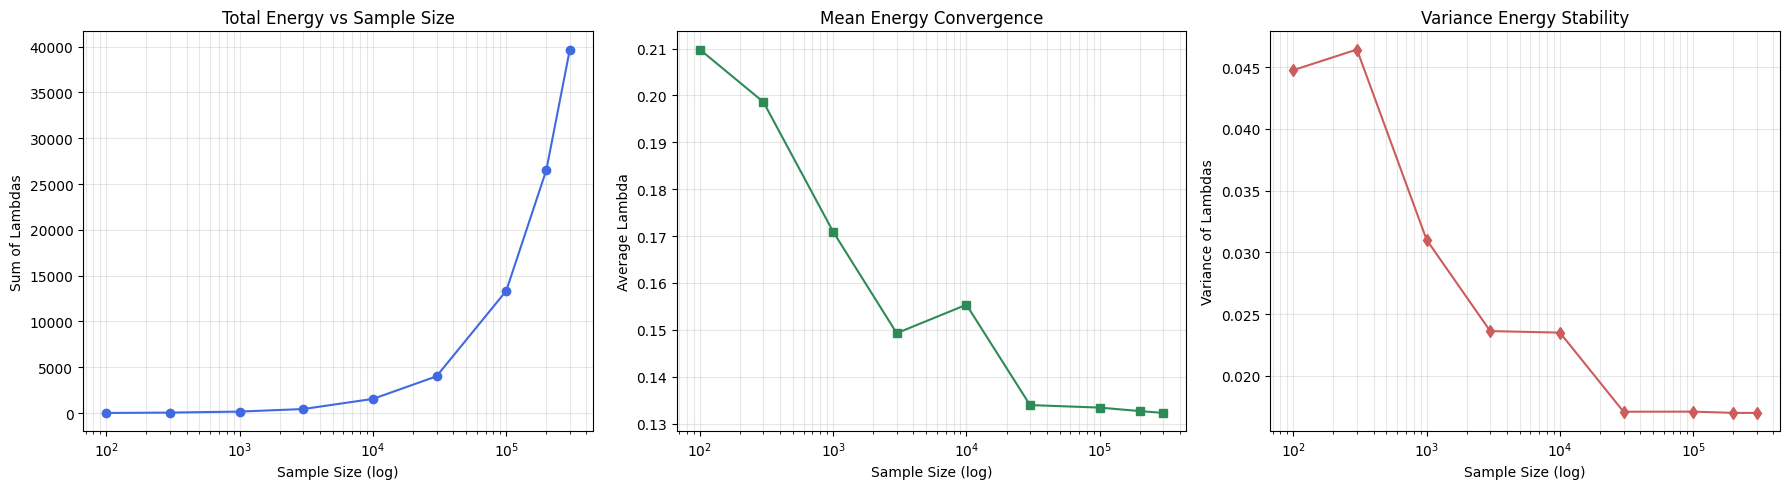

In [ ]:

# 1. Prepare the data
# We reset the index to turn the (Size, Seed) MultiIndex into regular columns
plot_df = results.reset_index()
plot_df.columns = ['Size', 'Seed', 'Total Energy', 'Mean Energy', 'Variance Energy']

# 2. Create the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total Energy (Growth)
axes[0].plot(plot_df['Size'], plot_df['Total Energy'], marker='o', color='royalblue')
axes[0].set_title('Total Energy vs Sample Size')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample Size (log)')
axes[0].set_ylabel('Sum of Lambdas')
axes[0].grid(True, which="both", alpha=0.3)

# Plot 2: Mean Energy (Convergence)
axes[1].plot(plot_df['Size'], plot_df['Mean Energy'], marker='s', color='seagreen')
axes[1].set_title('Mean Energy Convergence')
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample Size (log)')
axes[1].set_ylabel('Average Lambda')
axes[1].grid(True, which="both", alpha=0.3)

# Plot 3: Variance Energy (Stability)
axes[2].plot(plot_df['Size'], plot_df['Variance Energy'], marker='d', color='indianred')
axes[2].set_title('Variance Energy Stability')
axes[2].set_xscale('log')
axes[2].set_xlabel('Sample Size (log)')
axes[2].set_ylabel('Variance of Lambdas')
axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Second run with different parameters size 

In [11]:
params_1 = {
    'eps':10.849781, 'k':18, 'topk':306, 'p':2.862820, 'sigma':0.40962
}
sample_sizes = [100, 300, 1000, 3000, 10000, 30000, 100000, 200000, 300000]
seeds = [55]

results_1, lmbs_1 = compute_energy_metrics(df, params_1, sample_sizes, seeds)

build time: 0.653618s 
build time: 2.405423s 
build time: 21.974539s 
build time: 35.898908s 
build time: 35.162631s 
build time: 75.178551s 
build time: 210.584558s 
build time: 362.024503s 
build time: 449.273834s 


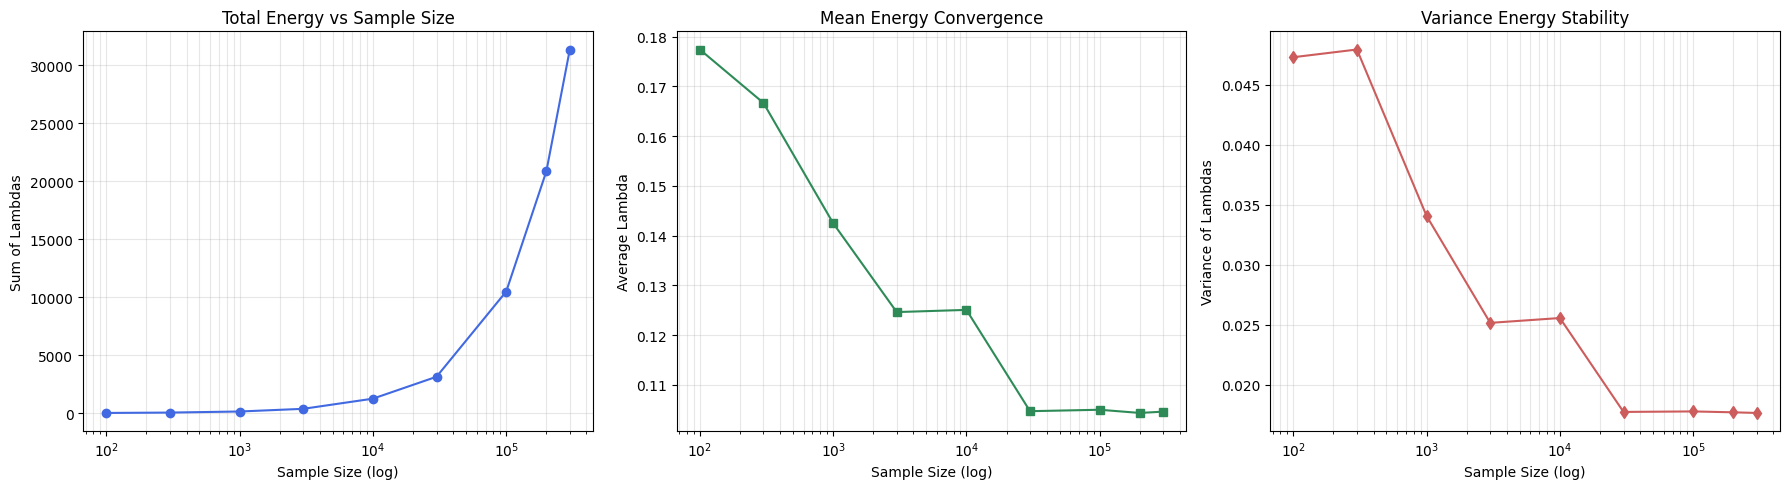

In [12]:

# 1. Prepare the data
# We reset the index to turn the (Size, Seed) MultiIndex into regular columns
plot_df_1 = results_1.reset_index()
plot_df_1.columns = ['Size', 'Seed', 'Total Energy', 'Mean Energy', 'Variance Energy']

# 2. Create the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total Energy (Growth)
axes[0].plot(plot_df_1['Size'], plot_df_1['Total Energy'], marker='o', color='royalblue')
axes[0].set_title('Total Energy vs Sample Size')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample Size (log)')
axes[0].set_ylabel('Sum of Lambdas')
axes[0].grid(True, which="both", alpha=0.3)

# Plot 2: Mean Energy (Convergence)
axes[1].plot(plot_df_1['Size'], plot_df_1['Mean Energy'], marker='s', color='seagreen')
axes[1].set_title('Mean Energy Convergence')
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample Size (log)')
axes[1].set_ylabel('Average Lambda')
axes[1].grid(True, which="both", alpha=0.3)

# Plot 3: Variance Energy (Stability)
axes[2].plot(plot_df_1['Size'], plot_df_1['Variance Energy'], marker='d', color='indianred')
axes[2].set_title('Variance Energy Stability')
axes[2].set_xscale('log')
axes[2].set_xlabel('Sample Size (log)')
axes[2].set_ylabel('Variance of Lambdas')
axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd

def find_convergence_threshold(df, graph_params, start_size=1000, step_factor=2.0, tolerance=1e-4):
    """
    Dynamically searches for the minimum sample size needed for the ArrowSpace 
    Laplacian to topologically converge on a new dataset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The full dataset to sample from.
    graph_params : dict
        The ArrowSpace parameters (eps, k, etc.).
    start_size : int
        The initial sample size to test.
    step_factor : float
        The multiplier for the next sample size (2.0 means it doubles each step).
    tolerance : float
        The convergence threshold for the change in variance (delta).
        
    Returns:
    --------
    int
        The optimal subsample size for this dataset.
    """
    max_samples = len(df)
    current_size = start_size
    prev_variance = float('inf')
    
    print(f"Searching for topological convergence (Tolerance: {tolerance})...")
    print("-" * 55)
    print(f"{'Size':>10} | {'Variance':>12} | {'Delta':>12}")
    print("-" * 55)
    
    while current_size <= max_samples:
        # 1. Sample without replacement (we want actual dataset items now)
        sample_df = df.sample(n=current_size, random_state=42, replace=False)
        arr = np.array(sample_df)
        
        # 2. Build graph and extract lambdas
        aspace, _ = build_arrowspace(graph_params, arr)
        lambdas = aspace.lambdas()
        
        # 3. Calculate current variance
        current_variance = np.var(lambdas)
        
        # 4. Calculate the rate of change (delta)
        delta = abs(prev_variance - current_variance)
        
        print(f"{current_size:>10} | {current_variance:>12.6f} | {delta:>12.6f}")
        
        # 5. The Generalized Rule: Stop if delta is below tolerance
        if delta < tolerance and current_size > start_size:
            print("-" * 55)
            print(f"✅ SUCCESS: Manifold converged at ~{current_size} items.")
            print(f"You only need {(current_size/max_samples)*100:.2f}% of this dataset.")
            return current_size
            
        # Prep for next iteration
        prev_variance = current_variance
        
        # Step up the size, but cap it at the dataset's max size
        next_size = int(current_size * step_factor)
        if current_size == max_samples:
            break # We've tested the whole dataset
        current_size = min(next_size, max_samples)
            
    print("-" * 55)
    print("⚠️ WARNING: Dataset fully evaluated without crossing tolerance threshold.")
    return max_samples

In [12]:
params = {
    'eps': 3.180912, 
    'k': 17.0, 
    'topk': 204.0, 
    'p': 2.24425, 
    'sigma': 0.985255
}

In [13]:
cve_topology_conv = find_convergence_threshold(df, params)

Searching for topological convergence (Tolerance: 0.0001)...
-------------------------------------------------------
      Size |     Variance |        Delta
-------------------------------------------------------
build time: 10.380561s 
      1000 |     0.036110 |          inf
build time: 16.889145s 
      2000 |     0.030912 |     0.005198
build time: 19.303225s 
      4000 |     0.030214 |     0.000698
build time: 13.224765s 
      8000 |     0.020345 |     0.009869
build time: 17.543483s 
     16000 |     0.019405 |     0.000940
build time: 33.192355s 
     32000 |     0.019518 |     0.000113
build time: 62.305368s 
     64000 |     0.019370 |     0.000148
build time: 122.068923s 
    128000 |     0.018461 |     0.000909
build time: 239.085065s 
    256000 |     0.016997 |     0.001464
build time: 300.194015s 
    313841 |     0.016964 |     0.000033
-------------------------------------------------------
✅ SUCCESS: Manifold converged at ~313841 items.
You only need 100.00% of this

# Randomized energy test

a test runned on 3 different bootstrapped samples of various sizes over 5 configurations of arrowspace paramenters

In [ ]:
# Cell 1 — imports
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cell 2 — paths
BASE = Path(".")

METRICS_PATH = BASE / "metrics.parquet"
LAMBDAS_PATH = BASE / "lambdas.pkl"
PARAMS_PATH = BASE / "params.json"
CONFIG_PATH = BASE / "experiment_config.json"

In [ ]:
# Cell 3 — load config + params
with open(CONFIG_PATH) as f:
    config = json.load(f)

with open(PARAMS_PATH) as f:
    params = pd.DataFrame(json.load(f))

print("Config:")
print(config)
print("\nParams:")
display(params)

In [ ]:
# Cell 4 — load metrics with fallback from lambdas.pkl
try:
    metrics = pd.read_parquet(METRICS_PATH).reset_index()
    print("Loaded metrics.parquet")
except Exception as e:
    print("Could not read metrics.parquet, rebuilding metrics from lambdas.pkl")
    print("Reason:", e)

    with open(LAMBDAS_PATH, "rb") as f:
        lambda_records = pickle.load(f)

    metrics = pd.DataFrame([
        {
            "trial": r["trial"],
            "sample_size": r["sample_size"],
            "seed": r["seed"],
            "Total Energy": float(np.sum(r["lambdas"])),
            "Mean Energy": float(np.mean(r["lambdas"])),
            "Variance Energy": float(np.var(r["lambdas"])),
        }
        for r in lambda_records
    ])

metrics = metrics.sort_values(["trial", "seed", "sample_size"]).reset_index(drop=True)
display(metrics.head())
print(metrics.shape)

In [ ]:
# Cell 5 — join params for easier analysis
metrics_full = metrics.merge(params, on="trial", how="left")
display(metrics_full.head())

In [ ]:
# Cell 6 — aggregated summary by sample size
summary = (
    metrics_full
    .groupby("sample_size")
    .agg(
        total_mean=("Total Energy", "mean"),
        total_std=("Total Energy", "std"),
        mean_mean=("Mean Energy", "mean"),
        mean_std=("Mean Energy", "std"),
        var_mean=("Variance Energy", "mean"),
        var_std=("Variance Energy", "std"),
    )
    .reset_index()
)

summary["var_pct_change_vs_prev"] = summary["var_mean"].pct_change() * 100
summary["mean_pct_change_vs_prev"] = summary["mean_mean"].pct_change() * 100

display(summary)

In [ ]:
# Cell 7 — plot total / mean / variance vs sample size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].errorbar(
    summary["sample_size"], summary["total_mean"], yerr=summary["total_std"],
    marker="o", capsize=4
)
axes[0].set_xscale("log")
axes[0].set_title("Total Energy vs Sample Size")
axes[0].set_xlabel("Sample size")
axes[0].set_ylabel("Total Energy")

axes[1].errorbar(
    summary["sample_size"], summary["mean_mean"], yerr=summary["mean_std"],
    marker="o", capsize=4
)
axes[1].set_xscale("log")
axes[1].set_title("Mean Energy vs Sample Size")
axes[1].set_xlabel("Sample size")
axes[1].set_ylabel("Mean Energy")

axes[2].errorbar(
    summary["sample_size"], summary["var_mean"], yerr=summary["var_std"],
    marker="o", capsize=4
)
axes[2].set_xscale("log")
axes[2].set_title("Variance Energy vs Sample Size")
axes[2].set_xlabel("Sample size")
axes[2].set_ylabel("Variance Energy")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 8 — per-trial variance curves
plt.figure(figsize=(8, 5))

for trial_id, g in metrics_full.groupby("trial"):
    tmp = g.groupby("sample_size")["Variance Energy"].mean().reset_index()
    plt.plot(tmp["sample_size"], tmp["Variance Energy"], marker="o", label=f"trial {trial_id}")

plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("Variance Energy")
plt.title("Variance Energy by trial")
plt.legend()
plt.show()

In [ ]:
# Cell 9 — per-seed variance curves
plt.figure(figsize=(8, 5))

for seed, g in metrics_full.groupby("seed"):
    tmp = g.groupby("sample_size")["Variance Energy"].mean().reset_index()
    plt.plot(tmp["sample_size"], tmp["Variance Energy"], marker="o", label=f"seed {seed}")

plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("Variance Energy")
plt.title("Variance Energy by seed")
plt.legend()
plt.show()

In [ ]:
# Cell 10 — quantify trial sensitivity vs seed sensitivity
trial_sensitivity = (
    metrics_full
    .groupby(["sample_size", "seed"])["Variance Energy"]
    .std()
    .reset_index(name="std_across_trials")
)

seed_sensitivity = (
    metrics_full
    .groupby(["sample_size", "trial"])["Variance Energy"]
    .std()
    .reset_index(name="std_across_seeds")
)

print("Std of Variance Energy across trials (fixed size, seed):")
display(trial_sensitivity)

print("Std of Variance Energy across seeds (fixed size, trial):")
display(seed_sensitivity)

print("Average std across trials:", trial_sensitivity["std_across_trials"].mean())
print("Max std across trials:", trial_sensitivity["std_across_trials"].max())

print("Average std across seeds:", seed_sensitivity["std_across_seeds"].mean())
print("Max std across seeds:", seed_sensitivity["std_across_seeds"].max())

In [ ]:
# Cell 11 — automatic text conclusions
def draw_conclusions(summary_df, trial_sens_df, seed_sens_df):
    s = summary_df.copy().sort_values("sample_size")

    n0 = int(s.iloc[0]["sample_size"])
    n1 = int(s.iloc[-1]["sample_size"])

    mean0 = s.iloc[0]["mean_mean"]
    mean1 = s.iloc[-1]["mean_mean"]

    var0 = s.iloc[0]["var_mean"]
    var1 = s.iloc[-1]["var_mean"]

    var30k = float(s.loc[s["sample_size"] == 30000, "var_mean"].iloc[0]) if (s["sample_size"] == 30000).any() else None
    var100k = float(s.loc[s["sample_size"] == 100000, "var_mean"].iloc[0]) if (s["sample_size"] == 100000).any() else None

    avg_trial_std = trial_sens_df["std_across_trials"].mean()
    max_trial_std = trial_sens_df["std_across_trials"].max()

    avg_seed_std = seed_sens_df["std_across_seeds"].mean()
    max_seed_std = seed_sens_df["std_across_seeds"].max()

    print("Conclusions")
    print("-----------")
    print(f"1. Total Energy increases strongly with sample size, so it is not plateauing in absolute scale.")
    print(f"2. Mean Energy decreases from {mean0:.4f} at n={n0} to {mean1:.4f} at n={n1}.")
    print(f"3. Variance Energy decreases from {var0:.4f} at n={n0} to {var1:.4f} at n={n1}.")
    if var30k is not None and var100k is not None:
        pct = 100 * (var100k - var30k) / var30k
        print(f"4. From n=30000 to n=100000, Variance Energy changes from {var30k:.5f} to {var100k:.5f} ({pct:.2f}%).")
        print("   This suggests a practical plateau or near-plateau starting around 30000.")
    print(f"5. Parameter sensitivity is tiny: avg std across trials = {avg_trial_std:.8f}, max = {max_trial_std:.8f}.")
    print(f"6. Seed sensitivity is much larger: avg std across seeds = {avg_seed_std:.6f}, max = {max_seed_std:.6f}.")
    print("7. So, in this experiment, sample size and bootstrap draw matter much more than the tested ArrowSpace parameters.")

draw_conclusions(summary, trial_sensitivity, seed_sensitivity)